<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module4_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
# We are creating data based on the equation y = 5 + 3x + noise

X = 2 * np.random.rand(100, 1)
y = 5 + 3 * X + np.random.randn(100, 1)

Text(0, 0.5, 'y')

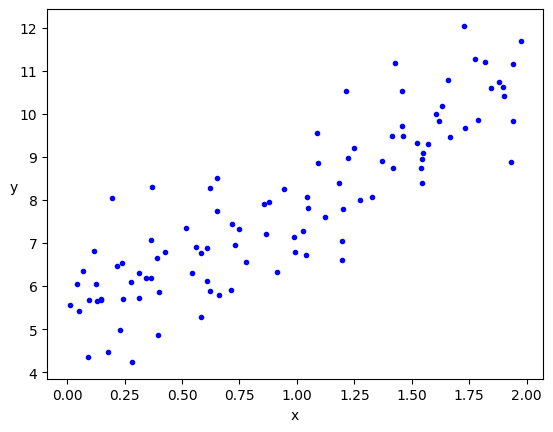

In [4]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

In [21]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))

    return cost

In [26]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):

    m = len(y)

    cost_history = np.zeros(iterations)

    # Automatically adapt to number of parameters
    y_pred_history = np.zeros((iterations, y_pred.shape[0]))

    for it in range(iterations):

        prediction = np.dot(X, y_pred)

        y_pred = y_pred - (1 / m) * learning_rate * (
            X.T.dot(prediction - y)
        )

        y_pred_history[it, :] = y_pred.flatten()

        cost_history[it] = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

In [7]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.800
y_pred[1]: 3.137
Final error: 4293.354


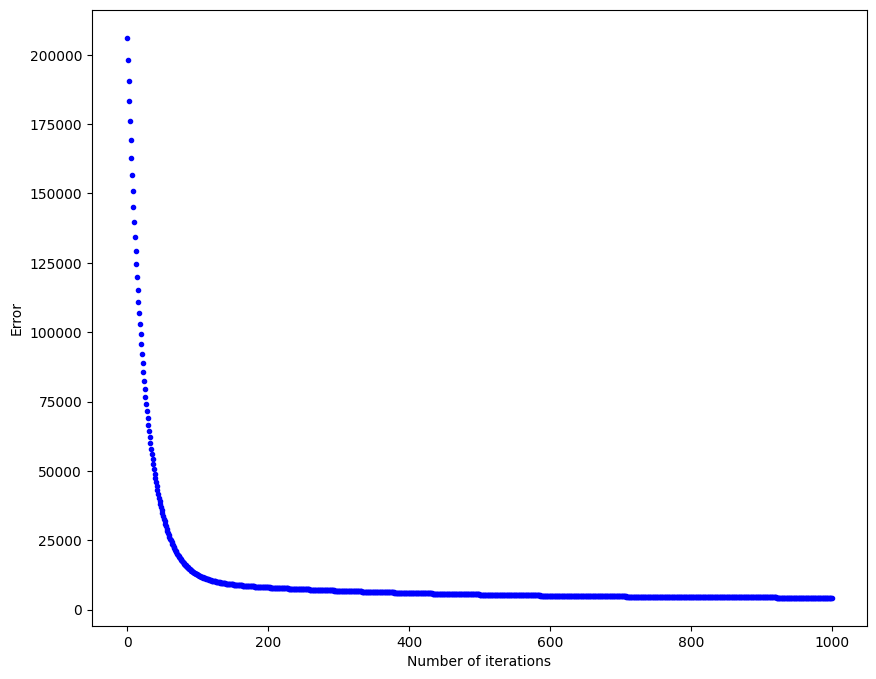

In [9]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

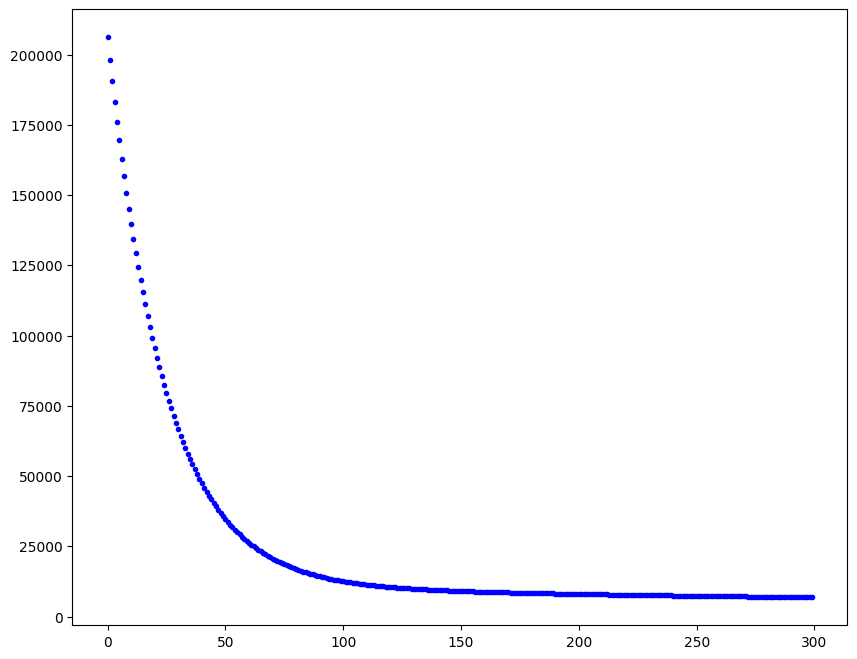

In [11]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(300), cost_history[:300], 'b.')

In [12]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [15]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 5.219
y_pred[1]: 2.805
Final error: 41.486


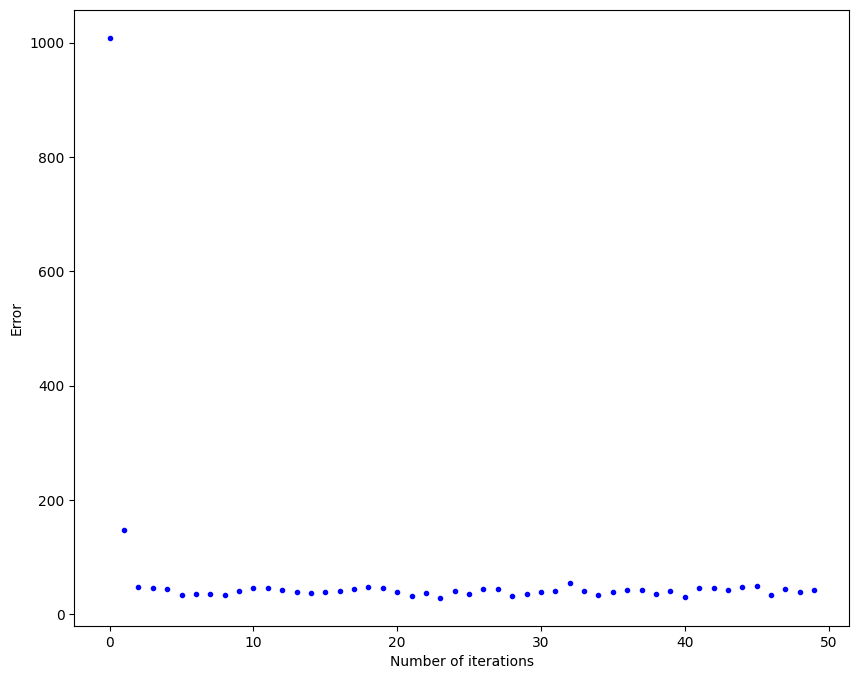

In [16]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

In [17]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [18]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 5.164
y_pred[1]: 2.820
Final error: 802.389


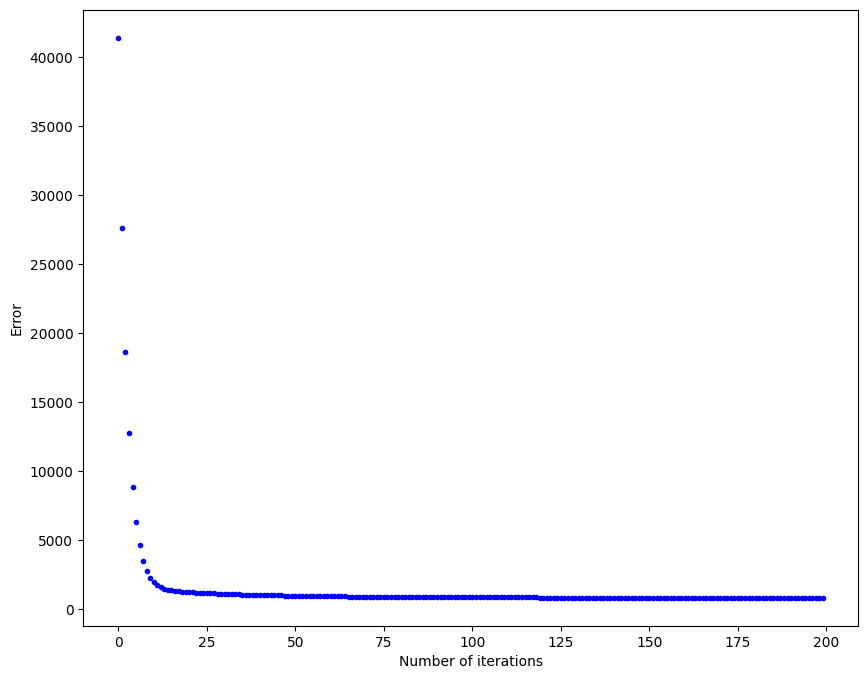

In [19]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

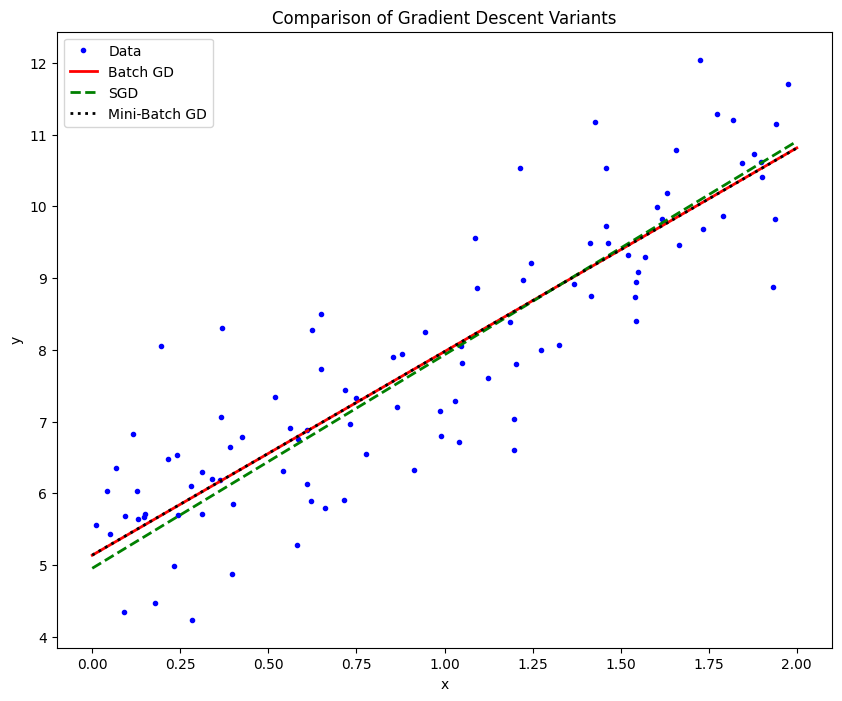

In [20]:
# Rerun all three for comparison
# Batch
lr_batch = 0.1
n_iter_batch = 200
y_pred_batch_final, _, _ = gradient_descent(X_b, y, np.random.randn(2,1), lr_batch, n_iter_batch)

# SGD
lr_sgd = 0.05
n_iter_sgd = 200
y_pred_sgd_final, _ = stocashtic_gradient_descent(X_b, y, np.random.randn(2,1), lr_sgd, n_iter_sgd)

# Mini-Batch
lr_mini = 0.1
n_iter_mini = 200
y_pred_mini_final, _ = minibatch_gradient_descent(X, y, np.random.randn(2,1), lr_mini, n_iter_mini)


# Plotting
plt.figure(figsize=(10, 8))
plt.plot(X, y, 'b.', label='Data')
# Create a set of X values for plotting the lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
# Get predictions for the lines
y_predict_batch = X_new_b.dot(y_pred_batch_final)
y_predict_sgd = X_new_b.dot(y_pred_sgd_final)
y_predict_mini = X_new_b.dot(y_pred_mini_final)

plt.plot(X_new, y_predict_batch, 'r-', linewidth=2, label='Batch GD')
plt.plot(X_new, y_predict_sgd, 'g--', linewidth=2, label='SGD')
plt.plot(X_new, y_predict_mini, 'k:', linewidth=2, label='Mini-Batch GD')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent Variants')
plt.legend()
plt.show()

### Things to Try Out

1. **Change batch size in mini-batch gradient descent:**
   Try a small size (e.g., `2`) and a large size (e.g., `80`). How does the loss curve change? What happens when the batch size equals the total number of samples?

2. **Test on real datasets:**
   Use a dataset from `sklearn.datasets`, like the **Boston Housing** or **Diabetes** datasets, and see how each variant performs.

3. **Compare learning rates:**
   Test the effects of changing the learning rate. Try a very high and a very low learning rate for each of the three variants. Which one is most sensitive to the learning rate?

4. **Implement a learning rate schedule for SGD:**
   Instead of a fixed learning rate, make it decrease over time (e.g., `lr = initial_lr / (epoch + 1)`). How does this affect the final error and the stability of the loss curve?


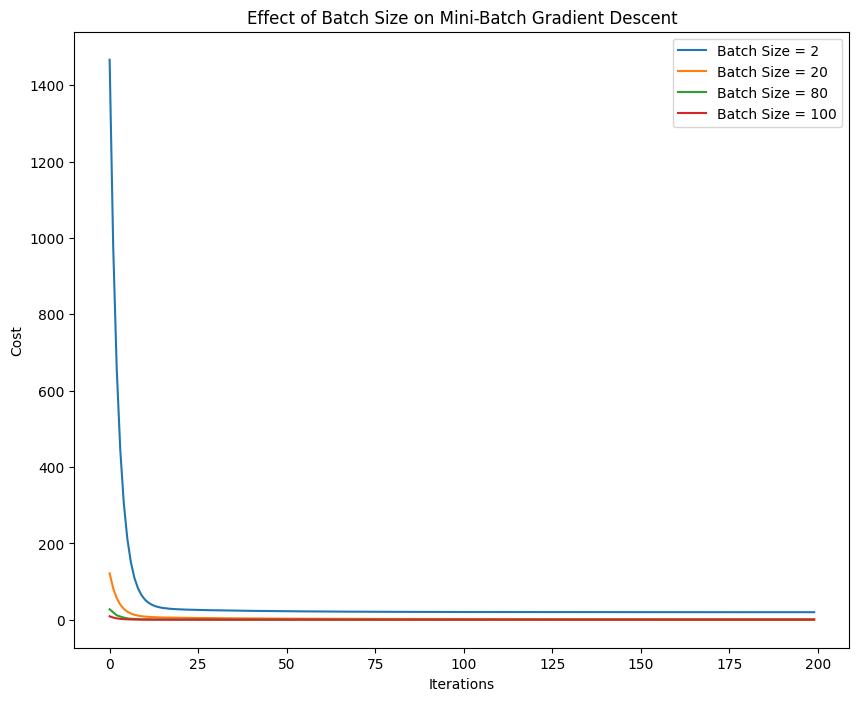

In [23]:
# Thing 1 : Change batch size in mini-batch gradient descent
batch_sizes = [2, 20, 80, 100]

plt.figure(figsize=(10,8))

for batch_size in batch_sizes:

    theta = np.random.randn(2,1)

    theta, cost_history = minibatch_gradient_descent(
        X,
        y,
        theta,
        learning_rate=0.1,
        iterations=200,
        batch_size=batch_size
    )

    plt.plot(
        range(200),
        cost_history,
        label=f'Batch Size = {batch_size}'
    )

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Effect of Batch Size on Mini-Batch Gradient Descent')
plt.legend()
plt.show()

Thing 2 : Test on real datasets

In [24]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

X_d = data.data
y_d = data.target.reshape(-1,1)

X_d_b = np.c_[np.ones((len(X_d),1)), X_d]

print("X shape:", X_d.shape)
print("y shape:", y_d.shape)

X shape: (442, 10)
y shape: (442, 1)


In [27]:
# Batch GD

theta_batch = np.random.randn(X_d_b.shape[1],1)

theta_batch, batch_cost, _ = gradient_descent(
    X_d_b,
    y_d,
    theta_batch,
    learning_rate=0.1,
    iterations=200
)

print("Batch GD Final Error:", batch_cost[-1])

Batch GD Final Error: 2624.9547691799216


In [28]:
# SGD

theta_sgd = np.random.randn(X_d_b.shape[1],1)

theta_sgd, sgd_cost = stocashtic_gradient_descent(
    X_d_b,
    y_d,
    theta_sgd,
    learning_rate=0.01,
    iterations=200
)

print("SGD Final Error:", sgd_cost[-1])

SGD Final Error: 1528195.1403814545


In [29]:
# Mini Batch GD

theta_mini = np.random.randn(X_d_b.shape[1],1)

theta_mini, mini_cost = minibatch_gradient_descent(
    X_d,
    y_d,
    theta_mini,
    learning_rate=0.1,
    iterations=200,
    batch_size=32
)

print("Mini Batch GD Final Error:", mini_cost[-1])

Mini Batch GD Final Error: 36831.93035839226


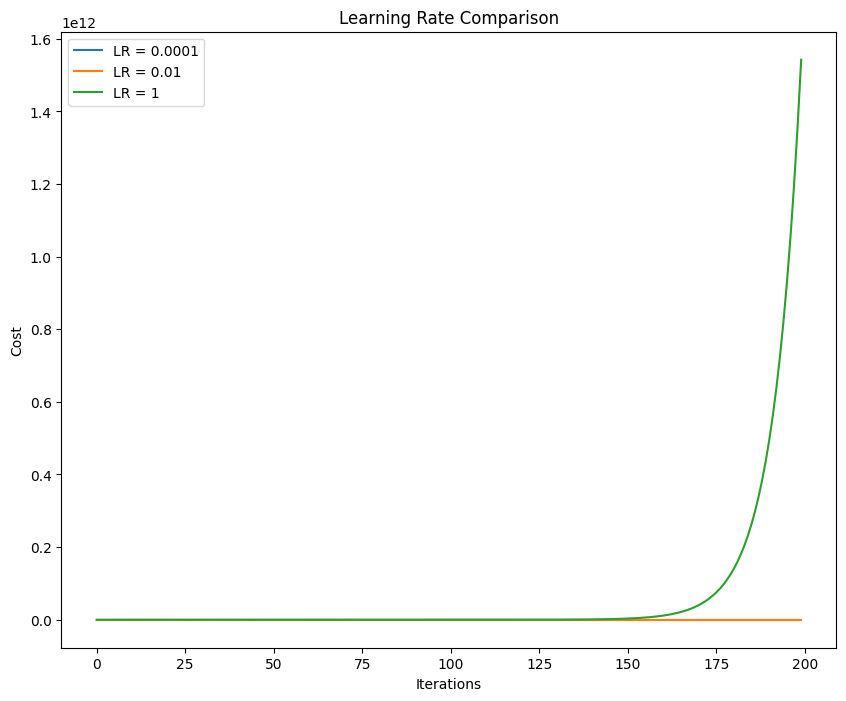

In [30]:
# Thing 3 : Compare Learning Rates
learning_rates = [0.0001, 0.01, 1]

plt.figure(figsize=(10,8))

for lr in learning_rates:

    theta = np.random.randn(2,1)

    theta, cost_history, _ = gradient_descent(
        X_b,
        y,
        theta,
        learning_rate=lr,
        iterations=200
    )

    plt.plot(
        range(200),
        cost_history,
        label=f'LR = {lr}'
    )

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Rate Comparison')
plt.legend()
plt.show()

Thing 4 : SGD with Learning Rate Schedule

In [31]:
def sgd_with_schedule(X, y, theta, initial_lr=0.5, iterations=50):

    m = len(y)

    cost_history = np.zeros(iterations)

    for epoch in range(iterations):

        lr = initial_lr / (epoch + 1)

        cost = 0

        for i in range(m):

            rand_ind = np.random.randint(0,m)

            X_i = X[rand_ind,:].reshape(1,X.shape[1])
            y_i = y[rand_ind].reshape(1,1)

            prediction = np.dot(X_i, theta)

            theta = theta - (1/m) * lr * (
                X_i.T.dot(prediction - y_i)
            )

            cost += cal_cost(theta, X_i, y_i)

        cost_history[epoch] = cost

    return theta, cost_history

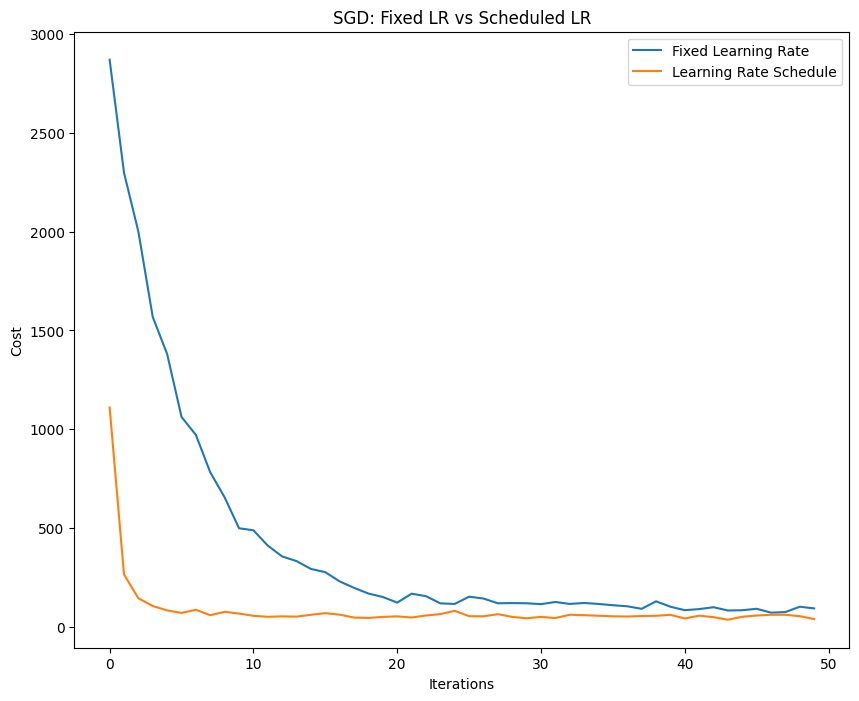

In [32]:
theta_fixed = np.random.randn(2,1)

theta_fixed, fixed_cost = stocashtic_gradient_descent(
    X_b,
    y,
    theta_fixed,
    learning_rate=0.05,
    iterations=50
)

theta_sched = np.random.randn(2,1)

theta_sched, sched_cost = sgd_with_schedule(
    X_b,
    y,
    theta_sched,
    initial_lr=0.5,
    iterations=50
)

plt.figure(figsize=(10,8))

plt.plot(
    range(50),
    fixed_cost,
    label='Fixed Learning Rate'
)

plt.plot(
    range(50),
    sched_cost,
    label='Learning Rate Schedule'
)

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('SGD: Fixed LR vs Scheduled LR')
plt.legend()
plt.show()